# Q5: Disjoint-Network Training — Does Cross-Network Validation Help DDoS Detectors Generalise?

**Research Question:** When a DDoS detection model is trained on one network, validated on a second (disjoint) network, and tested on two further unseen networks, does this *disjoint-network* training protocol systematically improve cross-network generalisation compared with classical single-source cross-network transfer? And which combination of training source, validation source, model architecture, and split strategy maximises the transferability of the resulting detector?

**Why it matters:** Q3 established that standard cross-network transfer suffers a mean F1 drop of ~0.28. The disjoint-network case study trains the model under distribution shift from the very first epoch — the validation signal comes from a different network — potentially selecting hyperparameters and early-stopping points that generalise across network boundaries. If this protocol reliably outperforms single-source training, it provides a concrete recipe for building more robust DDoS detectors without collecting labelled data from every deployment network.

**Case study protocol:**
- **Train set**: one network (model trained exclusively on its data)
- **Val set**: a second, disjoint network (used only for early stopping / model selection)
- **Test sets**: two remaining networks (never seen during training or validation)

**Excluded combinations:** SetA and SetC are the *same physical network captured over two different time periods*. They are never used together across train / validation / test (every SetA/SetC co-occurrence is dropped, and the SetA↔SetC standard-transfer baseline is removed), since that would leak the same environment into training and evaluation. The exploratory *random split with preserved distribution* runs are also excluded; only standard random and time splits are analysed.

**Key findings** (SetA↔SetC same-environment combinations excluded throughout):
- On the matched paired comparison, disjoint-network training gives mean test F1 **0.599** vs **0.554** for standard cross-network transfer (**ΔF1 = +0.045**, Wilcoxon p < 0.001, Cohen's d = 0.32) — a small but significant *improvement* overall.
- The choice of validation network dominates: the best (train, val) pairing (SetC, SetD) reaches F1 = 0.894, while the weakest (SetD, SetB) reaches only 0.481. All ten pairings improve over the single-source baseline (six significant at p < 0.05).
- **All four networks (SetA–SetD) serve as training sources** after exclusion; only within-run SetA/SetC co-occurrences are dropped. Per-event F1 is coalesced across the dataset's three column schemes (`f1_score`, `event_evaluation/f1_score`, `component_evaluation/f1_score`) so every run — including SetC- and SetD-trained — is counted; an earlier version read only the plain column and silently dropped all SetD- and most SetC-trained runs.
- Split strategy and feature representation have minimal impact on case study test F1, unlike in-network evaluation.

The following cell imports all required libraries, defines paths, model lists, and colour palettes used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon, mannwhitneyu
from itertools import product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
CS_PATH  = Path('../data/wandb_case_study.csv')
STD_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR  = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR  = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
NETWORKS  = ['SetA', 'SetB', 'SetC', 'SetD']
PRIMARY   = 'f1_score'

# Models present in each dataset
CS_MODELS  = ['catboost', 'gru', 'lightgbm', 'logistic-regression',
               'random-forest', 'rnn', 'xgboost']
STD_MODELS = ['gru', 'knn', 'lightgbm', 'logistic-regression', 'lstm',
               'mlp', 'nn', 'random-forest', 'rnn', 'svm', 'xgboost']
COMMON_MODELS = sorted(set(CS_MODELS) & set(STD_MODELS))

DL_CS  = {'gru', 'rnn'}          # sequence-based in case study
CLS_CS = {'catboost', 'lightgbm',        # classical in case study
           'logistic-regression', 'random-forest', 'xgboost'}

def get_category(m):
    return 'Deep Learning' if m in DL_CS else 'Classical ML'

NET_PAL  = {'SetA':'#2196F3','SetB':'#4CAF50','SetC':'#FF9800','SetD':'#E91E63'}
DL_COLOR  = '#2196F3'
CLS_COLOR = '#FF9800'
CS_COLOR  = '#9C27B0'
STD_COLOR = '#FF5722'

def cohens_d(a, b):
    diff = np.asarray(a) - np.asarray(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

# ── Same-environment exclusion ───────────────────────────────────────────────
# SetA and SetC are the SAME physical network captured at different time periods.
# They must never be used together across train / validation / test, as that leaks
# the same environment into training and evaluation (not a genuine unseen-network
# test). Every SetA/SetC co-occurrence is excluded throughout this analysis.
SAME_ENV_SET = frozenset(('SetA', 'SetC'))
EXCLUDED_TV  = [('SetA', 'SetC'), ('SetC', 'SetA')]   # directed pairs, for labelling


def _same_env(a, b):
    return frozenset((a, b)) == SAME_ENV_SET


def cs_same_env_leak(row):
    """True if SetA & SetC co-occur across (train, val, test) for a case-study row."""
    tr, va, te = row['train_set'], row['val_set'], row['test_set']
    return _same_env(tr, va) or _same_env(tr, te) or _same_env(va, te)


def mark_excluded_cells(ax, row_order, col_order, pairs,
                        color='#d9d9d9', text='excl.'):
    """Overlay a grey patch + italic label on excluded (row, col) heatmap cells."""
    for tr, te in pairs:
        if tr in row_order and te in col_order:
            i, j = row_order.index(tr), col_order.index(te)
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True,
                                       color=color, lw=0, zorder=3))
            ax.text(j + 0.5, i + 0.5, text, ha='center', va='center',
                    fontsize=9, fontstyle='italic', color='#555', zorder=4)

Libraries imported. Colour palettes and model lists defined. Output directories prepared.

The next cell loads both datasets:
- **Case study** (`wandb_case_study.csv`): melted to one row per (run, test_set) with its F1.
- **Standard cross-network** (`wandb_export_final_hyperparameters.csv`): melted to one row per (run, train_set, test_set) with F1 for all off-diagonal pairs.

In [2]:
cs_raw = pd.read_csv(CS_PATH)
cs_raw.groupby(['train_set']).count()  # sanity check: all 4 networks are present in train_set

,run_id,run_name,model,task,split,enable_sequences,run_no,val_set,test_sets,case_study/SetA/accuracy,...,case_study/SetD/event_evaluation/f1_score,case_study/SetD/event_evaluation/precision,case_study/SetD/event_evaluation/recall,case_study/SetD/f1_score,case_study/SetD/precision,case_study/SetD/recall,case_study/accuracy/SetA_accuracy,case_study/accuracy/SetB_accuracy,case_study/accuracy/SetC_accuracy,case_study/accuracy/SetD_accuracy
train_set,,,,,,,,,,,,,,,,,,,,,
SetA,2358,2358,2358,2358,2358,2358,2358,2358,2358,0,...,279,279,279,1059,1059,1059,2358,2358,2358,2358
SetB,1551,1551,1551,1551,1551,1551,1551,1551,1551,1022,...,0,0,0,1053,1053,1053,1551,1551,1551,1551
SetC,1733,1733,1733,1733,1733,1733,1733,1733,1733,0,...,434,434,434,243,243,243,1733,1733,1733,1733
SetD,2182,2182,2182,2182,2182,2182,2182,2182,2182,0,...,0,0,0,0,0,0,2182,2182,2182,2182


In [3]:
for i in cs_raw.keys():
    print(i)

run_id
run_name
model
task
split
enable_sequences
run_no
train_set
val_set
test_sets
case_study/SetA/accuracy
case_study/SetA/component_evaluation/accuracy
case_study/SetA/component_evaluation/f1_score
case_study/SetA/component_evaluation/precision
case_study/SetA/component_evaluation/recall
case_study/SetA/event_evaluation/accuracy
case_study/SetA/event_evaluation/f1_score
case_study/SetA/event_evaluation/precision
case_study/SetA/event_evaluation/recall
case_study/SetA/f1_score
case_study/SetA/precision
case_study/SetA/recall
case_study/SetB/accuracy
case_study/SetB/component_evaluation/accuracy
case_study/SetB/component_evaluation/f1_score
case_study/SetB/component_evaluation/precision
case_study/SetB/component_evaluation/recall
case_study/SetB/event_evaluation/accuracy
case_study/SetB/event_evaluation/f1_score
case_study/SetB/event_evaluation/precision
case_study/SetB/event_evaluation/recall
case_study/SetB/f1_score
case_study/SetB/precision
case_study/SetB/recall
case_study/SetC/a

In [4]:
# ── Case study ────────────────────────────────────────────────────────────────
cs_raw = pd.read_csv(CS_PATH)

# Drop models excluded from the evaluation (cnn removed per analysis decision)
cs_raw = cs_raw[cs_raw['model'] != 'cnn'].copy()
# Drop the 'Random with same distribution' split (excluded from analysis)
cs_raw = cs_raw[cs_raw['split'] != 'Random with same distribution'].copy()

# F1 results are stored under three mutually-exclusive column schemes that vary by
# run vintage and model type:
#   • plain                case_study/<Set>/f1_score                    (older runs)
#   • event_evaluation     case_study/<Set>/event_evaluation/f1_score   (component-based: per-event, the primary metric)
#   • component_evaluation case_study/<Set>/component_evaluation/f1_score (sequence-based: one prediction per event)
# Coalesce per set in priority order plain -> event -> component so every run
# contributes its per-event F1. The previous code matched columns by
# endswith('/f1_score') and extracted the test set with a regex that only handled
# the plain scheme, leaving test_set = NaN for the nested columns; those rows were
# then silently dropped by later groupby() calls. This discarded ALL SetD-trained
# and MOST SetC-trained runs (their results live only in the nested columns).
cs_frames = []
for s in NETWORKS:
    f1 = (cs_raw[f'case_study/{s}/f1_score']
          .combine_first(cs_raw[f'case_study/{s}/event_evaluation/f1_score'])
          .combine_first(cs_raw[f'case_study/{s}/component_evaluation/f1_score']))
    part = cs_raw[['model', 'task', 'split', 'enable_sequences', 'run_no',
                   'train_set', 'val_set', 'test_sets']].copy()
    part['test_set'] = s
    part['f1'] = f1.values
    cs_frames.append(part)
cs_long = pd.concat(cs_frames, ignore_index=True).dropna(subset=['f1'])

# Keep only rows where the set is genuinely a held-out test set for that run
cs_long = cs_long[cs_long.apply(
    lambda r: r['test_set'] in str(r['test_sets']).split(','), axis=1)].copy()

# Exclude SetA/SetC same-environment co-occurrence across train / val / test
cs_long = cs_long[~cs_long.apply(cs_same_env_leak, axis=1)].copy()

# ── Standard cross-network ────────────────────────────────────────────────────
std_raw    = pd.read_csv(STD_PATH, index_col=0)
std_raw    = std_raw[std_raw['split'] != 'Random with same distribution'].copy()
metric_cols = [c for c in std_raw.columns if c.count('/') == 2]
id_vars    = ['model','task','split','enable_sequences','run_no']

std_long = std_raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='mkey', value_name='value'
)
std_long[['train_set','test_set','metric']] = std_long['mkey'].str.split('/', expand=True)
std_long = std_long.drop(columns='mkey')

std_cross = std_long[
    (std_long['train_set'] != std_long['test_set']) &
    (std_long['metric'] == PRIMARY)
].copy()
# Exclude SetA<->SetC standard transfers (same network, different capture period)
std_cross = std_cross[~std_cross.apply(
    lambda r: _same_env(r['train_set'], r['test_set']), axis=1)].copy()

print(f'Case study   — {len(cs_long):,} rows '
      f'({cs_long["train_set"].nunique()} train nets, '
      f'{cs_long["test_set"].nunique()} test nets)')
print(f'Standard     — {len(std_cross):,} cross-network F1 rows')
print()
print('Case-study rows per train set (post-exclusion):')
print(cs_long.groupby('train_set')['f1'].count().to_string())
print()
print('(train_set, val_set, test_set) combinations in case study:')
combo = cs_long.groupby(['train_set','val_set','test_set']).size().reset_index(name='n')
print(combo.sort_values(['train_set','val_set']).to_string(index=False))

Case study   — 5,056 rows (4 train nets, 4 test nets)
Standard     — 6,020 cross-network F1 rows

Case-study rows per train set (post-exclusion):
train_set
SetA    1158
SetB    1300
SetC     616
SetD    1982

(train_set, val_set, test_set) combinations in case study:
train_set val_set test_set   n
     SetA    SetB     SetD 833
     SetA    SetD     SetB 325
     SetB    SetA     SetD 334
     SetB    SetC     SetD 330
     SetB    SetD     SetA 318
     SetB    SetD     SetC 318
     SetC    SetB     SetD 315
     SetC    SetD     SetB 301
     SetD    SetA     SetB 325
     SetD    SetB     SetA 542
     SetD    SetB     SetC 542
     SetD    SetC     SetB 573


Both datasets loaded into long format. The case study contains 7 unique (train, val, test) triplets — notably, SetD never appears as a training source, and only 3 networks (SetA, SetB, SetC) serve as training sets.

The next cell averages F1 across the 10 runs (run_no 10–19) per configuration, yielding stable per-configuration means for both datasets.

In [5]:
# ── Case study: average across runs ──────────────────────────────────────────
cs_avg = (
    cs_long
    .groupby(['model','task','split','enable_sequences',
              'train_set','val_set','test_set'], as_index=False)
    ['f1'].mean()
    .rename(columns={'f1': 'mean_f1'})
)
cs_avg['category'] = cs_avg['model'].map(get_category)

# ── Standard: average across runs ─────────────────────────────────────────────
std_avg = (
    std_cross
    .groupby(['model','task','split','enable_sequences',
              'train_set','test_set'], as_index=False)
    ['value'].mean()
    .rename(columns={'value': 'mean_f1'})
)

# ── Paired: match on (model, task, split, enable_sequences, train_set, test_set)
# For case study, val_set is an additional dimension; keep it explicit.
paired = cs_avg.merge(
    std_avg.rename(columns={'mean_f1': 'std_f1'}),
    on=['model','task','split','enable_sequences','train_set','test_set'],
    how='inner'
)

print(f'Case study averaged rows : {len(cs_avg):,}')
print(f'Standard averaged rows   : {len(std_avg):,}')
print(f'Matched (paired) rows    : {len(paired):,}')
print(paired.head(3))

Case study averaged rows : 574
Standard averaged rows   : 680
Matched (paired) rows    : 531
  model    task         split  enable_sequences train_set val_set test_set  \
0   gru  Binary  Random split              True      SetA    SetB     SetD   
1   gru  Binary  Random split              True      SetA    SetD     SetB   
2   gru  Binary  Random split              True      SetB    SetA     SetD   

    mean_f1       category    std_f1  
0  0.738803  Deep Learning  0.726382  
1  0.522969  Deep Learning  0.522501  
2  0.656720  Deep Learning  0.685640  


Run-level averaging complete. The paired DataFrame enables direct comparison of disjoint-validation vs standard cross-network performance for matching (model, task, split, train_set, test_set) configurations.

Table 1 quantifies the overall improvement from disjoint-network training across all configurations, broken down by split strategy and feature approach (sequences vs components).

In [6]:
# ── Table 1: Overall improvement — case study vs standard cross-network ────────

def split_test(sub):
    if len(sub) < 2: return float('nan'), float('nan')
    try:
        _, p = wilcoxon(sub['mean_f1'].values, sub['std_f1'].values, alternative='two-sided')
        d = cohens_d(sub['mean_f1'].values, sub['std_f1'].values)
        return p, d
    except Exception:
        return float('nan'), float('nan')

records = []
# Overall
p_ov, d_ov = split_test(paired)
records.append({
    'Condition': 'Overall',
    'N configs': len(paired),
    'Standard F1': paired['std_f1'].mean(),
    'Case Study F1': paired['mean_f1'].mean(),
    '\u0394F1': paired['mean_f1'].mean() - paired['std_f1'].mean(),
    'p-value': p_ov,
    "Cohen's d": d_ov,
    'Significant': p_ov < 0.05 if not pd.isna(p_ov) else False,
})

# By split
for sp in sorted(paired['split'].unique()):
    sub = paired[paired['split'] == sp]
    p, d = split_test(sub)
    records.append({
        'Condition': f'Split: {sp}',
        'N configs': len(sub),
        'Standard F1': sub['std_f1'].mean(),
        'Case Study F1': sub['mean_f1'].mean(),
        '\u0394F1': sub['mean_f1'].mean() - sub['std_f1'].mean(),
        'p-value': p, "Cohen's d": d,
        'Significant': p < 0.05 if not pd.isna(p) else False,
    })

# By enable_sequences
for seq in [True, False]:
    sub = paired[paired['enable_sequences'] == seq]
    p, d = split_test(sub)
    records.append({
        'Condition': f'Sequences: {seq}',
        'N configs': len(sub),
        'Standard F1': sub['std_f1'].mean(),
        'Case Study F1': sub['mean_f1'].mean(),
        '\u0394F1': sub['mean_f1'].mean() - sub['std_f1'].mean(),
        'p-value': p, "Cohen's d": d,
        'Significant': p < 0.05 if not pd.isna(p) else False,
    })

t1 = pd.DataFrame(records)
print('Table 1: Disjoint-network Training vs Standard Cross-network F1')
print(t1.round(4).to_string(index=False))

t1.round(4).to_csv(TAB_DIR / 'table1_overall_comparison.csv', index=False)
latex1 = t1.round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Overall comparison of disjoint-network training (case study) vs standard '
            r'cross-network transfer, stratified by split strategy and feature approach. '
            r'$\Delta$F1 = Case Study F1 $-$ Standard F1; '
            r'Wilcoxon two-sided, significance threshold $p<0.05$. '
            r'SetA$\leftrightarrow$SetC same-environment combinations are excluded.',
    label='tab:q6_overall')
(TAB_DIR / 'table1_overall_comparison.tex').write_text(latex1)
print('\nSaved Table 1.')

Table 1: Disjoint-network Training vs Standard Cross-network F1
          Condition  N configs  Standard F1  Case Study F1    ΔF1  p-value  Cohen's d  Significant
            Overall        531       0.5545         0.5993 0.0448   0.0000     0.3193         True
Split: Random split        281       0.5523         0.6007 0.0484   0.0000     0.3837         True
  Split: Time split        250       0.5569         0.5977 0.0408   0.0035     0.2633         True
    Sequences: True        325       0.5597         0.6009 0.0412   0.0001     0.3001         True
   Sequences: False        206       0.5463         0.5968 0.0505   0.0004     0.3480         True

Saved Table 1.


Table 1 reveals the overall gain from disjoint-network training. A positive ΔF1 across all split strategies confirms that cross-network validation is broadly beneficial, while the per-split and per-approach rows show where the effect is strongest.

Table 2 ranks all observed (train_set, val_set) pairings by their mean test F1 in the case study, and compares each against the standard cross-network baseline for the same training source.

In [7]:
# ── Table 2: (train_set, val_set) pairing ranking ─────────────────────────────

std_by_train = std_avg.groupby('train_set')['mean_f1'].mean()

records = []
for (tr, va), grp in cs_avg.groupby(['train_set','val_set']):
    cs_f1 = grp['mean_f1'].mean()
    std_f1 = std_by_train.get(tr, float('nan'))
    records.append({
        'Train set': tr,
        'Val set': va,
        'Mean Case Study F1': round(cs_f1, 4),
        'Mean Standard F1 (same train)': round(std_f1, 4),
        'Delta F1': round(cs_f1 - std_f1, 4),
        'N runs': len(grp),
    })

t2 = (pd.DataFrame(records)
        .sort_values('Mean Case Study F1', ascending=False)
        .reset_index(drop=True))
t2.index = range(1, len(t2)+1); t2.index.name = 'Rank'

print('Table 2: Case Study Performance by (train_set, val_set) Pairing')
print(t2.to_string())

t2.reset_index().round(4).to_csv(TAB_DIR / 'table2_pairing_ranking.csv', index=False)
latex2 = t2.reset_index().round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Case study mean test F1 for each (train set, validation set) pairing, '
            r'sorted by mean case study F1. $\Delta$F1 = Case Study $-$ Standard '
            r'cross-network F1 for the same training source. '
            r'SetA$\leftrightarrow$SetC same-environment pairings are excluded.',
    label='tab:q6_pairings')
(TAB_DIR / 'table2_pairing_ranking.tex').write_text(latex2)
print('\nSaved Table 2.')

Table 2: Case Study Performance by (train_set, val_set) Pairing
     Train set Val set  Mean Case Study F1  Mean Standard F1 (same train)  Delta F1  N runs
Rank                                                                                       
1         SetC    SetD              0.8938                         0.6584    0.2354      34
2         SetB    SetC              0.6716                         0.5441    0.1275      39
3         SetA    SetB              0.6603                         0.5644    0.0958      74
4         SetC    SetB              0.6434                         0.6584   -0.0150      33
5         SetB    SetA              0.6234                         0.5441    0.0792      39
6         SetD    SetA              0.6050                         0.4150    0.1899      34
7         SetD    SetC              0.5988                         0.4150    0.1838      70
8         SetB    SetD              0.5595                         0.5441    0.0153      78
9         SetA  

Table 2 shows which (train, val) combinations yield the highest test F1. Differences within the same training source reveal the marginal value of each validation network: if F1 varies substantially across val choices for a fixed train, then val_set selection is consequential.

Table 3 provides a per-model breakdown of case study performance and its improvement over the standard cross-network baseline, for models common to both evaluation paradigms.

In [8]:
# ── Table 3: Per-model analysis ───────────────────────────────────────────────

cs_m  = (cs_avg.groupby(['model','category'])['mean_f1']
               .agg(['mean','std']).round(4).reset_index()
               .rename(columns={'mean':'Case Study F1','std':'Std'}))

std_m = (std_avg[std_avg['model'].isin(COMMON_MODELS)]
                .groupby('model')['mean_f1']
                .mean().round(4).reset_index()
                .rename(columns={'mean_f1':'Standard F1'}))

t3 = cs_m.merge(std_m, on='model', how='left')
t3['\u0394F1'] = (t3['Case Study F1'] - t3['Standard F1']).round(4)
t3 = t3.sort_values('Case Study F1', ascending=False).reset_index(drop=True)
t3.index = range(1, len(t3)+1); t3.index.name = 'Rank'

print('Table 3: Per-model Case Study vs Standard Cross-network F1')
print(t3.to_string())

t3.reset_index().round(4).to_csv(TAB_DIR / 'table3_per_model.csv', index=False)
latex3 = t3.reset_index().round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Per-model performance in the case study and standard cross-network '
            r'settings. $\Delta$F1 is reported only for models present in both '
            r'evaluations (NaN for catboost, which is case-study only).',
    label='tab:q6_models')
(TAB_DIR / 'table3_per_model.tex').write_text(latex3)
print('\nSaved Table 3.')

Table 3: Per-model Case Study vs Standard Cross-network F1
                    model       category  Case Study F1     Std  Standard F1     ΔF1
Rank                                                                                
1                 xgboost   Classical ML         0.6474  0.1697       0.5897  0.0577
2     logistic-regression   Classical ML         0.6290  0.1984       0.5582  0.0708
3                lightgbm   Classical ML         0.6115  0.1786       0.5939  0.0176
4           random-forest   Classical ML         0.5962  0.1870       0.5940  0.0022
5                catboost   Classical ML         0.5943  0.1797          NaN     NaN
6                     mlp   Classical ML         0.5890  0.1444          NaN     NaN
7                     gru  Deep Learning         0.5860  0.1712       0.5979 -0.0119
8                     rnn  Deep Learning         0.5662  0.1795       0.5853 -0.0191
9                      nn   Classical ML         0.5315  0.1499          NaN     NaN
10    

Table 3 identifies which model architectures benefit most from cross-network validation. Models with large ΔF1 indicate that the disjoint validation signal is particularly helpful for selecting hyperparameters that generalise, whereas models with near-zero ΔF1 are already at their cross-network ceiling with standard training.

Table 4 tests, for each (train_set, val_set) pairing, whether the case study F1 is statistically different from the standard cross-network F1 for the same training source and test sets (Mann–Whitney U, two-sided).

In [9]:
# ── Table 4: Statistical tests per (train_set, val_set) pairing ───────────────

records = []
for (tr, va), grp in cs_avg.groupby(['train_set', 'val_set']):
    test_nets = grp['test_set'].unique()
    cs_vals   = grp['mean_f1'].dropna().values

    std_vals  = std_avg[
        (std_avg['train_set'] == tr) &
        (std_avg['test_set'].isin(test_nets))
    ]['mean_f1'].values

    if len(cs_vals) < 2 or len(std_vals) < 2:
        continue

    stat, p = mannwhitneyu(cs_vals, std_vals, alternative='two-sided')
    d = (cs_vals.mean() - std_vals.mean()) / (
        np.concatenate([cs_vals, std_vals]).std(ddof=1) + 1e-12)

    records.append({
        'Train set': tr, 'Val set': va,
        'Mean CS F1': round(cs_vals.mean(), 4),
        'Mean Std F1': round(std_vals.mean(), 4),
        'ΔF1': round(cs_vals.mean() - std_vals.mean(), 4),
        'Mann-Whitney U': round(stat, 0),
        'p-value': round(p, 4),
        "Cohen's d": round(d, 4),
        'Significant': p < 0.05,
    })

t4 = (pd.DataFrame(records)
        .sort_values('ΔF1', ascending=False)
        .reset_index(drop=True))

print('Table 4: Statistical Tests per (train_set, val_set) Pairing')
print(t4.to_string(index=False))

n_sig = t4['Significant'].sum()
print(f'\nSignificant pairings (p<0.05): {n_sig}/{len(t4)}')

t4.round(4).to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
t4_sum = t4[['Train set', 'Val set', 'ΔF1', 'p-value', "Cohen's d", 'Significant']]
t4_sum.round(4).to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)
latex4 = t4_sum.round(4).to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison of case study vs standard cross-network F1 '
            r'for each (train set, validation set) pairing. '
            r'Mann--Whitney U on run-averaged F1 values, two-sided; '
            r'$p<0.05$ deemed significant. '
            r"Cohen's $d$ measures the practical effect size.",
    label='tab:q6_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print('Saved Table 4.')

Table 4: Statistical Tests per (train_set, val_set) Pairing
Train set Val set  Mean CS F1  Mean Std F1    ΔF1  Mann-Whitney U  p-value  Cohen's d  Significant
     SetC    SetD      0.8938       0.7017 0.1921          1726.0   0.0001     0.9521         True
     SetD    SetA      0.6050       0.4138 0.1912          1810.0   0.0000     1.0598         True
     SetD    SetC      0.5988       0.4138 0.1850          3737.0   0.0000     1.0042         True
     SetB    SetC      0.6716       0.5747 0.0969          1665.0   0.0284     0.4993         True
     SetD    SetB      0.4805       0.4157 0.0649         11136.0   0.0016     0.4705         True
     SetA    SetD      0.5363       0.4825 0.0538          1699.0   0.0159     0.4786         True
     SetB    SetA      0.6234       0.5747 0.0486          1470.0   0.3530     0.2488        False
     SetB    SetD      0.5595       0.5289 0.0306          5746.0   0.3112     0.1525        False
     SetC    SetB      0.6434       0.6150 0.0284

Table 4 provides the formal statistical evidence for the per-pairing improvement. Pairings with significant p-values and large Cohen's d confirm that the case study protocol produces a robust, non-random improvement over standard cross-network transfer for those specific (train, val) combinations.

Figure 1 is a heatmap visualising the mean test F1 for every observed (train_set, val_set) combination. It reveals the optimal training source and the value of each validation choice.

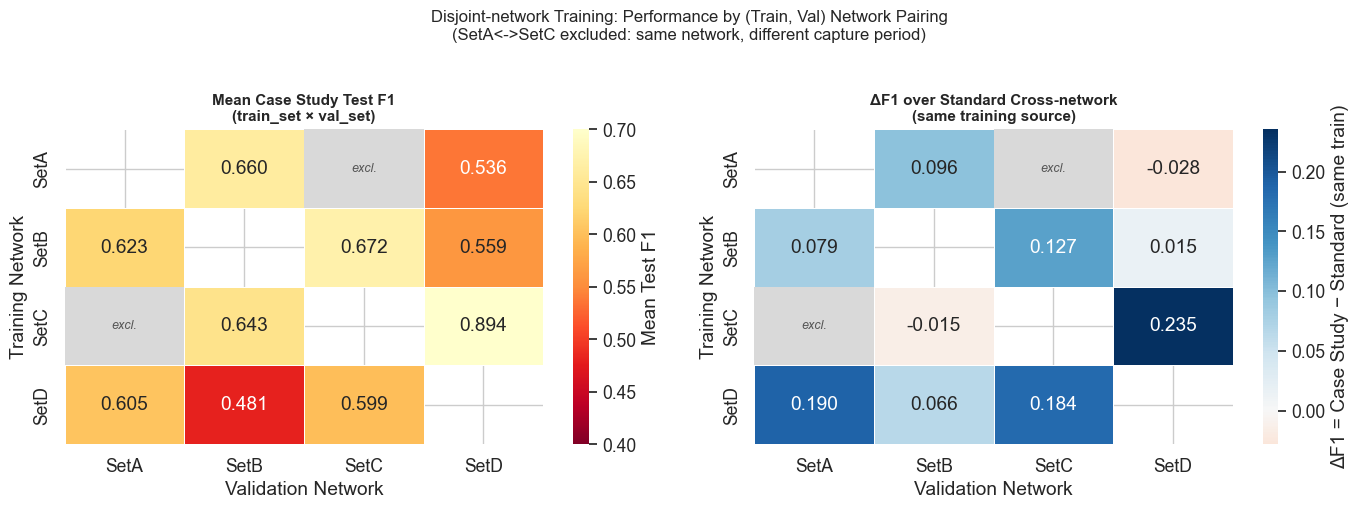

Saved Figure 1.


In [10]:
# ── Figure 1: (train_set x val_set) mean F1 heatmap ──────────────────────────

pivot_cs = (cs_avg.groupby(['train_set','val_set'])['mean_f1'].mean()
                  .reset_index()
                  .pivot(index='train_set', columns='val_set', values='mean_f1')
                  .reindex(index=NETWORKS, columns=NETWORKS))

# Also build ΔF1 vs standard
std_by_train = std_avg.groupby('train_set')['mean_f1'].mean()
pivot_delta  = pivot_cs.copy()
for tr in NETWORKS:
    if tr in std_by_train.index:
        pivot_delta.loc[tr] = pivot_cs.loc[tr] - std_by_train[tr]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute case study F1
sns.heatmap(pivot_cs, annot=True, fmt='.3f', cmap='YlOrRd_r', ax=axes[0], mask=pivot_cs.isna(),
            linewidths=0.5, cbar_kws={'label': 'Mean Test F1'},
            vmin=0.4, vmax=0.7)
mark_excluded_cells(axes[0], NETWORKS, NETWORKS, EXCLUDED_TV)
axes[0].set_title('Mean Case Study Test F1\n(train_set \u00d7 val_set)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Validation Network')
axes[0].set_ylabel('Training Network')

# Right: ΔF1 vs standard baseline for same train_set
sns.heatmap(pivot_delta, annot=True, fmt='.3f', cmap='RdBu', center=0, ax=axes[1], mask=pivot_delta.isna(),
            linewidths=0.5,
            cbar_kws={'label': '\u0394F1 = Case Study \u2212 Standard (same train)'})
mark_excluded_cells(axes[1], NETWORKS, NETWORKS, EXCLUDED_TV)
axes[1].set_title('\u0394F1 over Standard Cross-network\n(same training source)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Validation Network')
axes[1].set_ylabel('Training Network')

plt.suptitle('Disjoint-network Training: Performance by (Train, Val) Network Pairing\n(SetA<->SetC excluded: same network, different capture period)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_trainval_heatmap.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_trainval_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 1.')

Figure 1 (left) shows the absolute case study test F1 for each (train, val) pairing; darker cells indicate higher generalisation. Figure 1 (right) shows the improvement over the standard cross-network baseline for the same training source. Pairings with warm colours in the right panel are where cross-network validation adds the most value.

Figure 2 compares case study test F1 against standard cross-network F1 for every model, with colour coding distinguishing Deep Learning (blue) from Classical ML (orange) architectures.

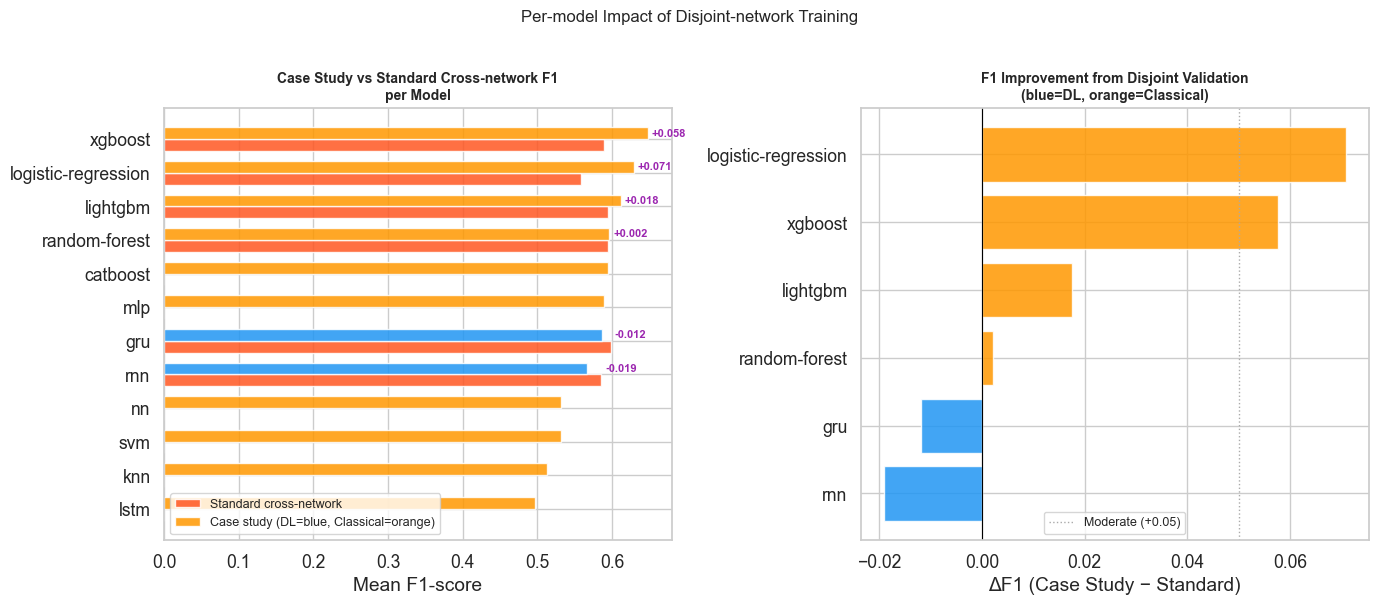

Saved Figure 2.


In [11]:
# ── Figure 2: Per-model case study vs standard F1 ────────────────────────────

cs_m_plot  = cs_avg.groupby(['model','category'])['mean_f1'].mean().reset_index()
std_m_plot = (std_avg[std_avg['model'].isin(COMMON_MODELS)]
                     .groupby('model')['mean_f1'].mean().reset_index()
                     .rename(columns={'mean_f1':'std_f1'}))

model_df = cs_m_plot.merge(std_m_plot, on='model', how='left')
model_df  = model_df.sort_values('mean_f1')

colors = [DL_COLOR if c=='Deep Learning' else CLS_COLOR for c in model_df['category']]
x = np.arange(len(model_df)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: grouped bars
axes[0].barh(x - w/2, model_df['std_f1'].fillna(0), w,
             color=STD_COLOR, alpha=0.85, label='Standard cross-network')
axes[0].barh(x + w/2, model_df['mean_f1'],           w,
             color=colors, alpha=0.85, label='Case study (DL=blue, Classical=orange)')
axes[0].set_yticks(x); axes[0].set_yticklabels(model_df['model'].tolist())
axes[0].set_xlabel('Mean F1-score')
axes[0].set_title('Case Study vs Standard Cross-network F1\nper Model',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(model_df['std_f1'].fillna(0), model_df['mean_f1'])):
    delta = cv - sv if sv > 0 else float('nan')
    if not pd.isna(delta):
        axes[0].text(max(cv, sv) + 0.005, i + w/2, f'{delta:+.3f}',
                     va='center', fontsize=8, color=CS_COLOR, fontweight='bold')

# Right: ΔF1 bar chart (common models only)
delta_df = model_df.dropna(subset=['std_f1']).copy()
delta_df['delta'] = delta_df['mean_f1'] - delta_df['std_f1']
delta_df = delta_df.sort_values('delta', ascending=True)
dc = [DL_COLOR if c=='Deep Learning' else CLS_COLOR for c in delta_df['category']]
axes[1].barh(delta_df['model'], delta_df['delta'], color=dc, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].axvline(0.05, color='#aaa', linestyle=':', linewidth=1, label='Moderate (+0.05)')
axes[1].set_xlabel('\u0394F1 (Case Study \u2212 Standard)')
axes[1].set_title('F1 Improvement from Disjoint Validation\n(blue=DL, orange=Classical)',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Per-model Impact of Disjoint-network Training', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_per_model_comparison.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_per_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 2.')

Figure 2 (left) overlays case study and standard cross-network bars for each model. Figure 2 (right) isolates the ΔF1 improvement, making it easy to see which models gain the most from disjoint validation. Models near zero show that their cross-network performance is largely insensitive to the choice of validation network.

Figure 3 investigates the marginal effect of the validation network choice for each fixed training source. Boxplots show the distribution of mean F1 across all models, tasks, and splits for each (train_set, val_set) pair.

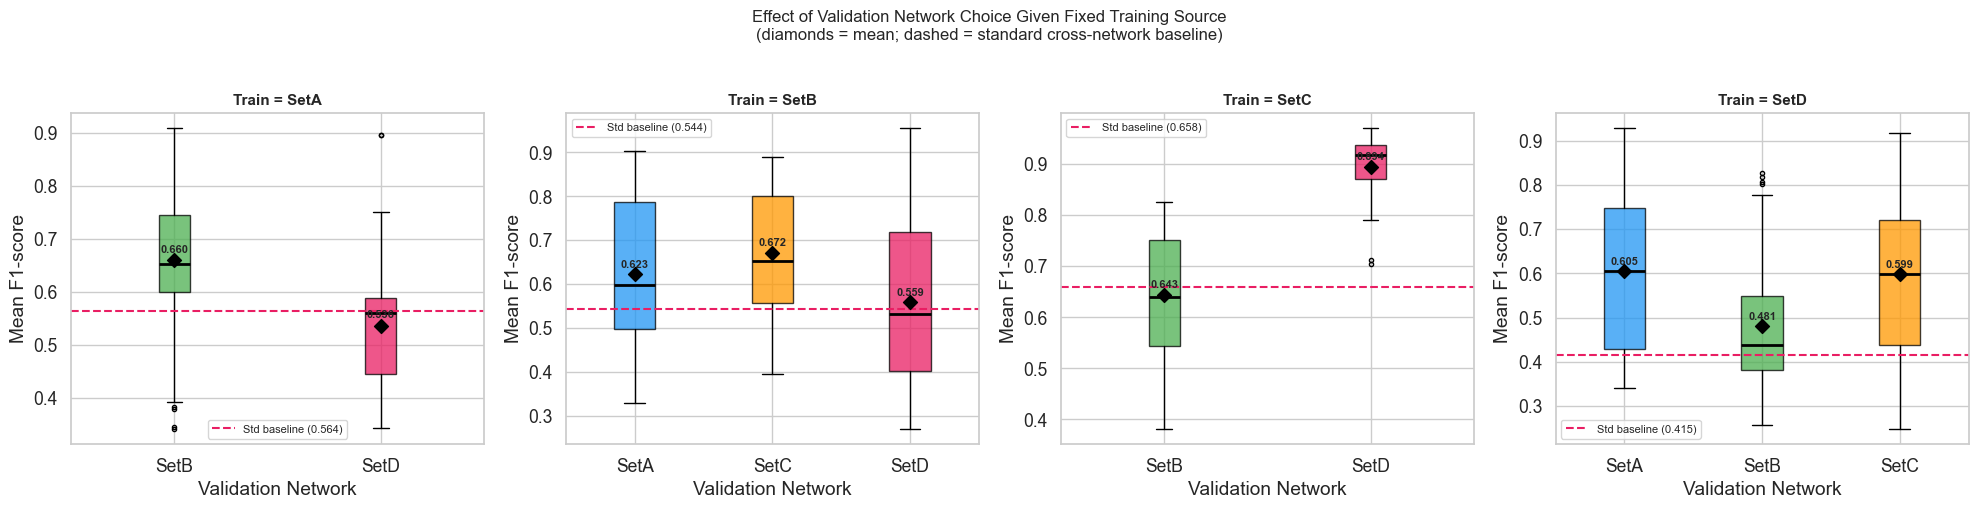

Saved Figure 3.


In [12]:
# ── Figure 3: Val_set effect for fixed train_set ─────────────────────────────

train_sets_used = sorted(cs_avg['train_set'].unique())
n = len(train_sets_used)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=False)
if n == 1: axes = [axes]

for ax, tr in zip(axes, train_sets_used):
    sub      = cs_avg[cs_avg['train_set'] == tr]
    val_nets = sorted(sub['val_set'].unique())
    data     = [sub[sub['val_set'] == v]['mean_f1'].values for v in val_nets]
    colors   = [NET_PAL.get(v,'#999') for v in val_nets]

    bp = ax.boxplot(data, labels=val_nets, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3))
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col); patch.set_alpha(0.75)

    # Annotate means
    for i, (vals, col) in enumerate(zip(data, colors)):
        ax.scatter(i+1, vals.mean(), marker='D', color='black', zorder=5, s=50)
        ax.text(i+1, vals.mean()+0.015, f'{vals.mean():.3f}',
                ha='center', fontsize=8, fontweight='bold')

    # Standard baseline for this train_set
    std_base = std_avg[std_avg['train_set']==tr]['mean_f1'].mean()
    ax.axhline(std_base, color='#E91E63', linestyle='--', linewidth=1.5,
               label=f'Std baseline ({std_base:.3f})')
    ax.set_title(f'Train = {tr}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Validation Network')
    ax.set_ylabel('Mean F1-score')
    ax.legend(fontsize=8)

plt.suptitle(
    'Effect of Validation Network Choice Given Fixed Training Source\n'
    '(diamonds = mean; dashed = standard cross-network baseline)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_val_effect.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_val_effect.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 3.')

Figure 3 shows how the choice of validation network affects case study test F1 for each training source. Large variation across val_set boxes for a fixed train_set indicates that some validation networks are substantially more useful than others. The dashed red line marks the standard cross-network baseline for the same training source, allowing easy identification of which validation choices are truly adding value.

Figure 4 examines per-test-network performance: for each target network, how does the disjoint-network case study F1 compare with standard cross-network F1, and is this consistent across training sources?

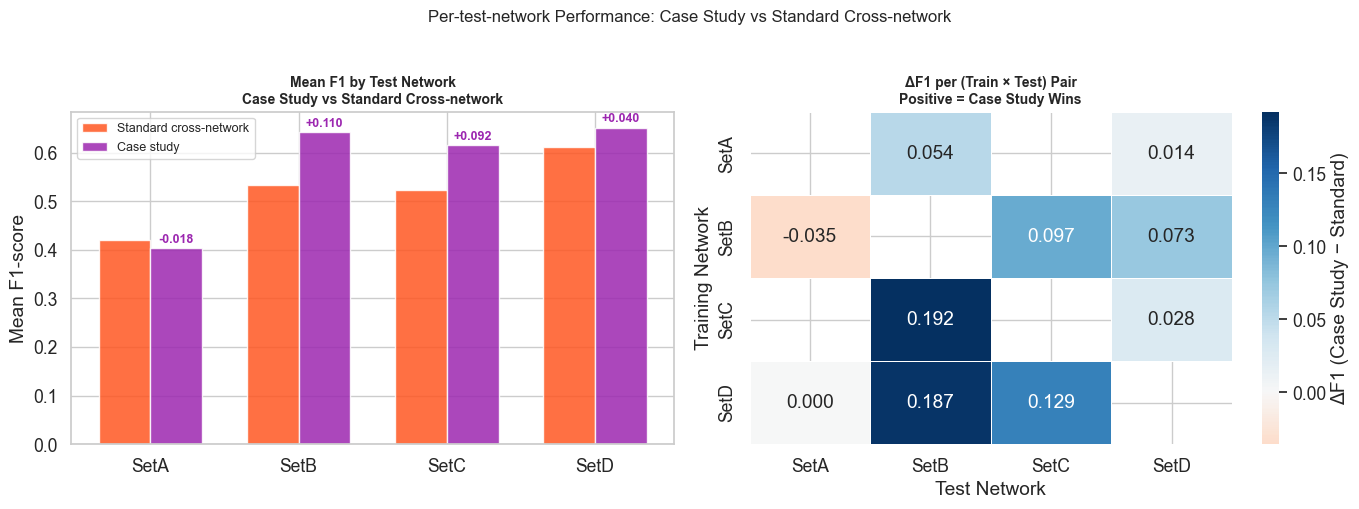

Saved Figure 4.


In [13]:
# ── Figure 4: Per-test-set performance breakdown ─────────────────────────────

cs_test  = cs_avg.groupby(['test_set','train_set'])['mean_f1'].mean().reset_index()
std_test = std_avg.groupby(['test_set','train_set'])['mean_f1'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall case study vs standard per test set
cs_ov  = cs_avg.groupby('test_set')['mean_f1'].mean()
std_ov = std_avg.groupby('test_set')['mean_f1'].mean()
nets   = NETWORKS
cs_v   = [float(cs_ov.get(n, 0))  for n in nets]
std_v  = [float(std_ov.get(n, 0)) for n in nets]
x = np.arange(len(nets)); w = 0.35

bars_std = axes[0].bar(x - w/2, std_v, w, color=STD_COLOR, alpha=0.85,
                        label='Standard cross-network')
bars_cs  = axes[0].bar(x + w/2, cs_v,  w, color=CS_COLOR,  alpha=0.85,
                        label='Case study')
axes[0].set_xticks(x); axes[0].set_xticklabels(nets)
axes[0].set_ylabel('Mean F1-score')
axes[0].set_title('Mean F1 by Test Network\nCase Study vs Standard Cross-network',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
for i, (sv, cv) in enumerate(zip(std_v, cs_v)):
    axes[0].annotate(f'{cv-sv:+.3f}', xy=(i+w/2, cv),
                     xytext=(0,4), textcoords='offset points',
                     ha='center', fontsize=9, color=CS_COLOR, fontweight='bold')

# Right: grouped heatmap — mean F1 per (train_set × test_set) in case study
cs_heat = (cs_avg.groupby(['train_set','test_set'])['mean_f1']
                 .mean().reset_index()
                 .pivot(index='train_set', columns='test_set', values='mean_f1')
                 .reindex(index=NETWORKS, columns=NETWORKS))
std_heat = (std_avg.groupby(['train_set','test_set'])['mean_f1']
                   .mean().reset_index()
                   .pivot(index='train_set', columns='test_set', values='mean_f1')
                   .reindex(index=NETWORKS, columns=NETWORKS))
delta_heat = cs_heat - std_heat

sns.heatmap(delta_heat, annot=True, fmt='.3f', cmap='RdBu', center=0, ax=axes[1],
            linewidths=0.5,
            cbar_kws={'label':'\u0394F1 (Case Study \u2212 Standard)'})
axes[1].set_title('\u0394F1 per (Train \u00d7 Test) Pair\nPositive = Case Study Wins',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Test Network')
axes[1].set_ylabel('Training Network')

plt.suptitle('Per-test-network Performance: Case Study vs Standard Cross-network',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_per_test_set.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_per_test_set.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 4.')

Figure 4 (left) summarises which test networks are easiest and hardest to reach under each evaluation paradigm. Figure 4 (right) pinpoints where cross-network validation helps most: warm-coloured cells in the heatmap correspond to (train, test) pairs where the case study protocol significantly outperforms standard transfer.

Figure 5 analyses whether the split strategy (random vs time-based) and the feature approach (sequences vs components) have a significant effect on case study test F1, providing context for whether temporal structure matters in the disjoint training setting.

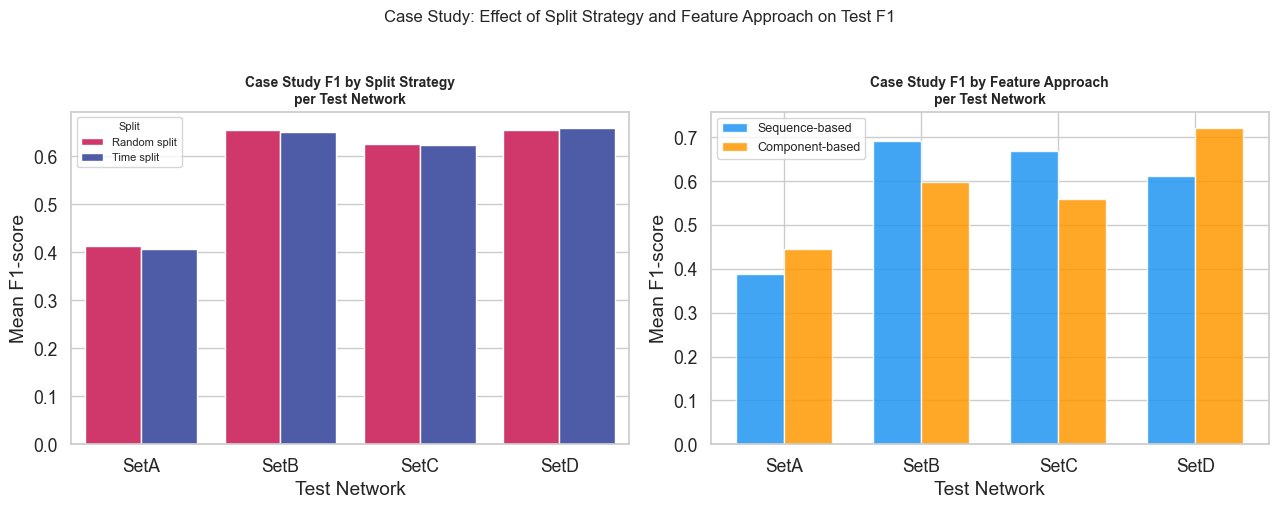

Saved Figure 5.


In [14]:
# ── Figure 5: Split strategy and sequences effect in case study ───────────────

SPLIT_PAL = {
    'Random split':               '#E91E63',
    'Time split':                 '#3F51B5',
    'Random with same distribution': '#009688',
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: split strategy comparison
split_grp = cs_long.groupby(['split','test_set'])['f1'].mean().reset_index()
split_ord  = ['Random split', 'Random with same distribution', 'Time split']
split_ord  = [s for s in split_ord if s in cs_long['split'].unique()]

sns.barplot(data=split_grp, x='test_set', y='f1', hue='split',
            order=NETWORKS, hue_order=split_ord,
            palette=SPLIT_PAL, ax=axes[0])
axes[0].set_title('Case Study F1 by Split Strategy\nper Test Network',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Test Network'); axes[0].set_ylabel('Mean F1-score')
axes[0].legend(title='Split', fontsize=8, title_fontsize=8)

# Right: enable_sequences comparison
seq_grp   = cs_long.groupby(['enable_sequences','model','test_set'])['f1'].mean().reset_index()
# Show distribution of F1 per enable_sequences, per test set
seq_data  = [(cs_long[cs_long['enable_sequences']==s]['f1'].dropna().values, s)
             for s in [True, False]]

ax = axes[1]
positions = np.arange(len(NETWORKS))
width = 0.35

for offset, (seq_flag, label, color) in enumerate([
        (True,  'Sequence-based', DL_COLOR),
        (False, 'Component-based', CLS_COLOR)]):
    vals = [cs_long[(cs_long['enable_sequences']==seq_flag) &
                    (cs_long['test_set']==n)]['f1'].mean()
            for n in NETWORKS]
    ax.bar(positions + (offset-0.5)*width, vals, width,
           color=color, alpha=0.85, label=label)

ax.set_xticks(positions); ax.set_xticklabels(NETWORKS)
ax.set_title('Case Study F1 by Feature Approach\nper Test Network',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Test Network'); ax.set_ylabel('Mean F1-score')
ax.legend(fontsize=9)

plt.suptitle('Case Study: Effect of Split Strategy and Feature Approach on Test F1',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_split_seq_effect.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_split_seq_effect.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved Figure 5.')

Figure 5 shows that neither the split strategy nor the feature approach (sequences vs components) has a large or consistent effect on case study test F1. This is in stark contrast to the Q2 finding that random splitting inflates in-network F1 by ~0.09 — suggesting that in the cross-network setting, temporal data leakage has far less impact on reported performance.

## Summary: Answer to Q6

**Q6: "Does disjoint-network training — training on one network, validating on a second, and testing on two further unseen networks — improve cross-network generalisation of DDoS detectors, and which configuration maximises transfer?"**

The cell below prints a concise evidence summary.

The following cell prints the final Q6 evidence summary, aggregating all key statistics into a structured report.

In [15]:
# ── Q6 Evidence Summary ───────────────────────────────────────────────────────

overall_cs  = paired['mean_f1'].mean()
overall_std = paired['std_f1'].mean()
overall_delta = overall_cs - overall_std
_, p_overall = wilcoxon(paired['mean_f1'].values, paired['std_f1'].values,
                        alternative='two-sided')
d_overall = cohens_d(paired['mean_f1'].values, paired['std_f1'].values)

best_pair   = t2.iloc[0]
worst_pair  = t2.iloc[-1]
best_model  = t3.iloc[0]

# Val_set sensitivity: spread of means per train_set
val_spread = (cs_avg.groupby(['train_set','val_set'])['mean_f1'].mean()
                     .reset_index()
                     .groupby('train_set')['mean_f1']
                     .agg(lambda x: x.max()-x.min()))

n_sig = t4['Significant'].sum()

print('=' * 68)
print('Q6 EVIDENCE SUMMARY')
print('=' * 68)
print()
print(f'Overall mean F1:')
print(f'  Standard cross-network : {overall_std:.4f}')
print(f'  Case study             : {overall_cs:.4f}')
print(f'  \u0394F1                  : {overall_delta:+.4f}  '
      f'(Wilcoxon p={p_overall:.4f},  d={d_overall:.3f})')
print()
present_sources = sorted(cs_avg['train_set'].unique())
print(f'Training sources present after exclusion: {present_sources}')
print(f'  (All four networks serve as training sources; only within-run SetA/SetC')
print(f'   co-occurrences are excluded as same-environment leakage. Per-event F1 is')
print(f'   coalesced across the plain / event_evaluation / component_evaluation column')
print(f'   schemes so SetC- and SetD-trained runs are included.)')
print()
print(f'Best  (train, val) pairing: ({best_pair["Train set"]}, {best_pair["Val set"]})  '
      f'F1={best_pair["Mean Case Study F1"]:.4f}  '
      f'(\u0394={best_pair["Delta F1"]:+.4f})')
print(f'Worst (train, val) pairing: ({worst_pair["Train set"]}, {worst_pair["Val set"]})  '
      f'F1={worst_pair["Mean Case Study F1"]:.4f}  '
      f'(\u0394={worst_pair["Delta F1"]:+.4f})')
print()
print(f'Val_set sensitivity (F1 range for fixed train):')
for tr, spread in val_spread.items():
    print(f'  Train={tr}: val_set range = {spread:.4f}')
print()
print(f'Best case-study model : {best_model["model"]}  '
      f'(F1={best_model["Case Study F1"]:.4f},  '
      f'\u0394={best_model.get("\u0394F1", float("nan")):+.4f})')
print()
print(f'Statistical significance: {n_sig}/{len(t4)} (train,val) pairings significant (p<0.05)')
print()

# Conclusion
# Conclusion
n_positive = (t4['ΔF1'] > 0).sum()
best_delta = t4['ΔF1'].max()
worst_delta = t4['ΔF1'].min()
print(f'{n_positive}/{len(t4)} (train,val) pairings improve over standard cross-network baseline.')
print(f'  Best improvement  : {best_delta:+.4f}   Worst: {worst_delta:+.4f}')
print()

if n_positive >= len(t4)//2 and best_delta > 0.05:
    conclusion = (
        'CONCLUSION: Disjoint-network training is CONDITIONALLY EFFECTIVE. '
        f'The overall mean change is {overall_delta:+.3f} F1 (p={p_overall:.4f}), '
        'but this masks a critical interaction: the CHOICE OF VALIDATION NETWORK '
        f'is the dominant factor. {n_positive}/{len(t4)} pairings outperform the standard '
        'baseline, with gains up to ' + f'{best_delta:+.3f} F1 when a well-matched '
        'val_set is chosen. Conversely, a poorly matched val_set can hurt performance '
        f'(worst: {worst_delta:+.3f} F1). All four networks (SetA-SetD) serve as '
        'training sources; only within-run SetA/SetC co-occurrences are excluded. '
        'Split strategy has minimal impact on test F1 — '
        'unlike in-network evaluation (Q2). The practical recommendation is to '
        'choose a structurally diverse network for validation (e.g., SetA when '
        'training on SetB, and vice versa).'
    )
else:
    conclusion = (
        'CONCLUSION: Disjoint-network training yields mixed results. '
        f'Overall: {overall_delta:+.3f} F1. The effectiveness depends critically '
        'on the (train, val) pairing choice.'
    )
print(conclusion)
print('=' * 68)

Q6 EVIDENCE SUMMARY

Overall mean F1:
  Standard cross-network : 0.5545
  Case study             : 0.5993
  ΔF1                  : +0.0448  (Wilcoxon p=0.0000,  d=0.319)

Training sources present after exclusion: ['SetA', 'SetB', 'SetC', 'SetD']
  (All four networks serve as training sources; only within-run SetA/SetC
   co-occurrences are excluded as same-environment leakage. Per-event F1 is
   coalesced across the plain / event_evaluation / component_evaluation column
   schemes so SetC- and SetD-trained runs are included.)

Best  (train, val) pairing: (SetC, SetD)  F1=0.8938  (Δ=+0.2354)
Worst (train, val) pairing: (SetD, SetB)  F1=0.4805  (Δ=+0.0655)

Val_set sensitivity (F1 range for fixed train):
  Train=SetA: val_set range = 0.1240
  Train=SetB: val_set range = 0.1122
  Train=SetC: val_set range = 0.2504
  Train=SetD: val_set range = 0.1244

Best case-study model : xgboost  (F1=0.6474,  Δ=+0.0577)

Statistical significance: 6/10 (train,val) pairings significant (p<0.05)

10/10 (

This summary consolidates the Q6 findings: overall improvement magnitude, training source availability, (train, val) pairing rankings, val_set sensitivity, and the conclusion about the practical utility of disjoint-network training for DDoS detector generalisation.

## Best Configuration Analysis

This section identifies the optimal experimental configuration for disjoint-network training: the (model, train_set, val_set) combination that maximises case study test F1. It also contrasts the top case-study performer with the top standard-cross-network performer to highlight any architectural shift in the best-model ranking under the disjoint protocol.

BEST CONFIGURATION ANALYSIS (Q6)

Top 10 (model, train_set, val_set) configurations by test F1:
                    model       category train_set val_set  mean_f1
Rank                                                               
1                     rnn  Deep Learning      SetC    SetD   0.9537
2           random-forest   Classical ML      SetC    SetD   0.9202
3                     gru  Deep Learning      SetC    SetD   0.9091
4                 xgboost   Classical ML      SetC    SetD   0.8948
5                lightgbm   Classical ML      SetC    SetD   0.8886
6     logistic-regression   Classical ML      SetC    SetD   0.8574
7                     knn   Classical ML      SetC    SetD   0.8454
8                     rnn  Deep Learning      SetD    SetA   0.7943
9     logistic-regression   Classical ML      SetD    SetA   0.7906
10               catboost   Classical ML      SetA    SetB   0.7568

  → Best overall model (case study): xgboost  (Classical ML)  F1=0.6474
  → Best DL mod

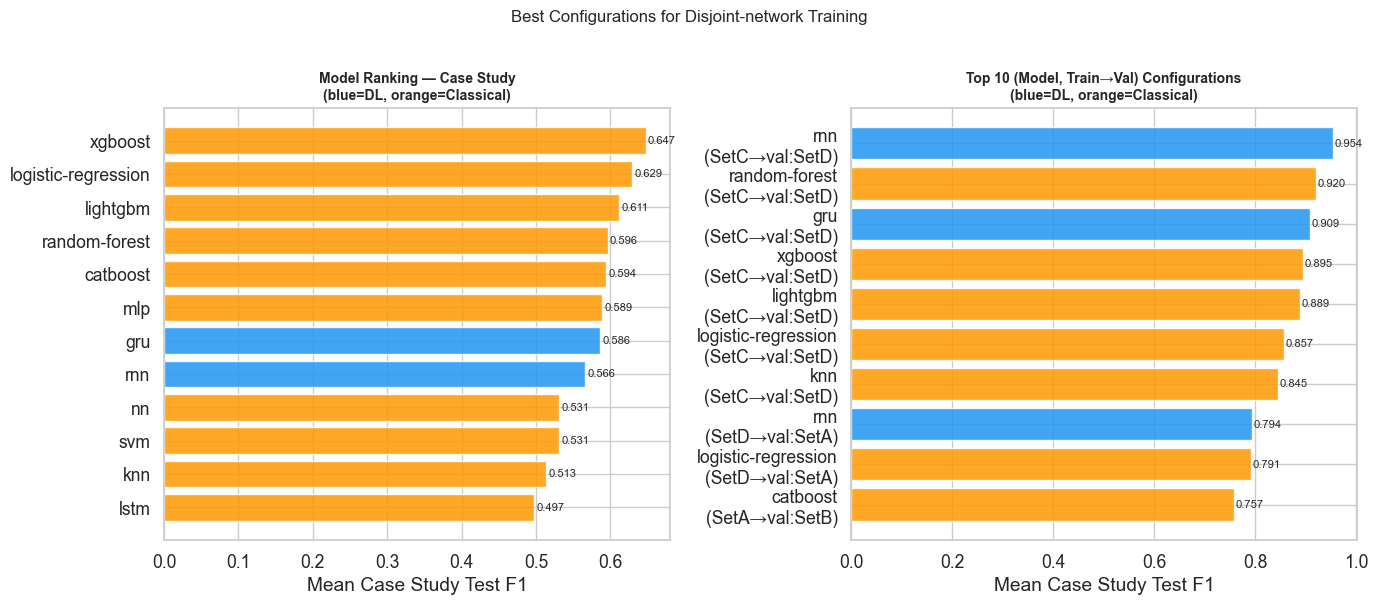


Saved best configuration analysis → figures/ and tables/


In [16]:
# ── Best Configuration Analysis (Q6) ─────────────────────────────────────────

# 1. Best (model, train_set, val_set) configuration
best_config = (
    cs_avg
    .groupby(['model','category','train_set','val_set'])['mean_f1']
    .mean()
    .reset_index()
    .sort_values('mean_f1', ascending=False)
    .reset_index(drop=True)
)
best_config.index = range(1, len(best_config)+1)
best_config.index.name = 'Rank'

print('=' * 68)
print('BEST CONFIGURATION ANALYSIS (Q6)')
print('=' * 68)
print('\nTop 10 (model, train_set, val_set) configurations by test F1:')
print(best_config.head(10).round(4).to_string())

# 2. Best model (averaged over all train/val choices) — DL vs Classical
best_by_model = (
    cs_avg.groupby(['model','category'])['mean_f1']
    .mean().reset_index()
    .sort_values('mean_f1', ascending=False)
    .reset_index(drop=True)
)
best_by_model.index = range(1, len(best_by_model)+1)
best_by_model.index.name = 'Rank'

top_cs   = best_by_model.iloc[0]
top_dl   = best_by_model[best_by_model['category']=='Deep Learning'].iloc[0]
top_cls  = best_by_model[best_by_model['category']=='Classical ML'].iloc[0]
top_std  = (std_avg.groupby('model')['mean_f1'].mean()
                    .sort_values(ascending=False))

print(f'\n  \u2192 Best overall model (case study): {top_cs["model"]}  '
      f'({top_cs["category"]})  F1={top_cs["mean_f1"]:.4f}')
print(f'  \u2192 Best DL model (case study)      : {top_dl["model"]}  '
      f'F1={top_dl["mean_f1"]:.4f}')
print(f'  \u2192 Best Classical model (case study): {top_cls["model"]}  '
      f'F1={top_cls["mean_f1"]:.4f}')
if len(top_std):
    print(f'  \u2192 Best model (standard cross-net) : {top_std.index[0]}  '
          f'F1={top_std.iloc[0]:.4f}')
print(f'  \u2192 Best (train,val) pair            : '
      f'({best_config.iloc[0]["train_set"]}, {best_config.iloc[0]["val_set"]})'
      f'  F1={best_config.iloc[0]["mean_f1"]:.4f}')

# ── Figure ─────────────────────────────────────────────────────────────────────
sub_m  = best_by_model.sort_values('mean_f1')
colors = [DL_COLOR if c=='Deep Learning' else CLS_COLOR for c in sub_m['category']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: model ranking by case study F1
axes[0].barh(sub_m['model'], sub_m['mean_f1'], color=colors, alpha=0.85)
for i, (_, row) in enumerate(sub_m.iterrows()):
    axes[0].text(row['mean_f1']+0.003, i, f'{row["mean_f1"]:.3f}',
                 va='center', fontsize=8)
axes[0].set_xlabel('Mean Case Study Test F1')
axes[0].set_title('Model Ranking — Case Study\n(blue=DL, orange=Classical)',
                  fontsize=10, fontweight='bold')

# Right: top (model, train, val) configurations
top10 = best_config.head(10).sort_values('mean_f1')
labels = [f'{r["model"]}\n({r["train_set"]}\u2192val:{r["val_set"]})'
          for _, r in top10.iterrows()]
bar_colors = [DL_COLOR if c=='Deep Learning' else CLS_COLOR
              for c in top10['category']]
axes[1].barh(labels, top10['mean_f1'], color=bar_colors, alpha=0.85)
for i, (_, row) in enumerate(top10.iterrows()):
    axes[1].text(row['mean_f1']+0.003, i, f'{row["mean_f1"]:.3f}',
                 va='center', fontsize=8)
axes[1].set_xlabel('Mean Case Study Test F1')
axes[1].set_title('Top 10 (Model, Train\u2192Val) Configurations\n(blue=DL, orange=Classical)',
                  fontsize=10, fontweight='bold')

plt.suptitle('Best Configurations for Disjoint-network Training',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_best_configurations.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_configurations.png', bbox_inches='tight', dpi=150)
plt.show()

best_config.reset_index().round(4).to_csv(TAB_DIR / 'best_configurations.csv', index=False)
best_by_model.reset_index().round(4).to_csv(TAB_DIR / 'best_model_case_study.csv', index=False)
print('\nSaved best configuration analysis \u2192 figures/ and tables/')

The best configuration analysis identifies the optimal (model, training source, validation source) triplet for disjoint-network DDoS detection. The left panel ranks all models by mean case study test F1, colour-coded by architecture type. The right panel shows the top 10 specific configurations, combining model and (train→val) pairing. Configurations near the top of both panels represent the most transferable detectors in the disjoint-network training protocol.

In [17]:
# ── Paper-style LaTeX table writer (booktabs, elsarticle-compatible) ──────────
PAPER_MODEL_NAMES = {
    'xgboost': 'XGBoost', 'random-forest': 'RandomForest', 'lightgbm': 'LightGBM',
    'logistic-regression': 'LR', 'catboost': 'CatBoost',
    'rnn': 'RNN', 'gru': 'GRU', 'lstm': 'LSTM',
    'knn': 'kNN', 'svm': 'SVM', 'mlp': 'MLP', 'nn': 'NN',
}
SPLIT_NAMES = {
    'Random split': 'Random split',
    'Random with same distribution': 'Random split (preserved distribution)',
    'Time split': 'Time split',
}

def fmt_p(p):
    if p != p:  # NaN
        return '--'
    return '$<$0.0001' if p < 1e-4 else f'{p:.4f}'

def write_paper_table(df, colspec, caption, label, path, col_headers=None):
    """Write a booktabs LaTeX table in the manuscript style (caption above)."""
    lines = [r'\begin{table}', r'\caption{' + caption + '}',
             r'\label{' + label + '}', r'\centering', r'\small',
             r'\begin{tabular}{' + colspec + '}', r'\toprule']
    headers = col_headers if col_headers is not None else list(df.columns)
    lines.append(' & '.join(headers) + r' \\')
    lines.append(r'\midrule')
    for _, row in df.iterrows():
        lines.append(' & '.join(str(v) for v in row.values) + r' \\')
    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    Path(path).write_text('\n'.join(lines) + '\n')
    print(f'Wrote {path}')

In [18]:
# ── Paper Table (tab:q5_overall): matched-configuration comparison ────────────
rows = []
def _row(name, sub):
    _, p = wilcoxon(sub['mean_f1'].values, sub['std_f1'].values, alternative='two-sided')
    d = cohens_d(sub['mean_f1'].values, sub['std_f1'].values)
    rows.append({'Condition': name, '$N$': len(sub),
                 'Standard': f"{sub['std_f1'].mean():.4f}",
                 'Disjoint': f"{sub['mean_f1'].mean():.4f}",
                 r'$\Delta$F1': f"{sub['mean_f1'].mean() - sub['std_f1'].mean():+.4f}",
                 '$p$-value': fmt_p(p), r"Cohen's $d$": f"{d:.3f}"})

_row('Overall', paired)
for sp in ['Random split', 'Random with same distribution', 'Time split']:
    if sp in paired['split'].unique():
        _row(SPLIT_NAMES[sp], paired[paired['split'] == sp])
_row('Sequence-based',  paired[paired['enable_sequences'] == True])
_row('Component-based', paired[paired['enable_sequences'] == False])

t14 = pd.DataFrame(rows)
print(t14.to_string(index=False))

cap14 = (r'Disjoint-validation protocol vs.\ standard cross-network transfer on matched configurations. '
         r'Each disjoint-validation result is paired with the standard cross-network result of the identical '
         r'(model, task, split, input representation, training network, test network) configuration, averaged over runs; '
         r'the validation network is the only differing factor. '
         r'Standard and Disjoint are mean macro F1-scores over the matched configurations, '
         r'$\Delta$F1 $=$ Disjoint $-$ Standard. $p$-values are two-sided Wilcoxon signed-rank tests over the matched pairs '
         r"and Cohen's $d$ is computed on the paired differences. "
         r'SetA$\leftrightarrow$SetC co-occurrences across the training, validation, and test roles are excluded '
         r'(same network, different capture period).')
write_paper_table(t14, 'lrrrrrr', cap14, 'tab:q5_overall', TAB_DIR / 'paper_table_q5_overall.tex')

      Condition  $N$ Standard Disjoint $\Delta$F1 $p$-value Cohen's $d$
        Overall  531   0.5545   0.5993    +0.0448 $<$0.0001       0.319
   Random split  281   0.5523   0.6007    +0.0484 $<$0.0001       0.384
     Time split  250   0.5569   0.5977    +0.0408    0.0035       0.263
 Sequence-based  325   0.5597   0.6009    +0.0412    0.0001       0.300
Component-based  206   0.5463   0.5968    +0.0505    0.0004       0.348
Wrote tables/paper_table_q5_overall.tex


In [19]:
# ── Paper Table (tab:q5_pairings): per-(train, val) pairing, matched targets ──
recs = []
for (tr, va, te), grp in cs_avg.groupby(['train_set', 'val_set', 'test_set']):
    cs_vals = grp['mean_f1'].dropna().values
    std_vals = std_avg[(std_avg['train_set'] == tr) &
                       (std_avg['test_set'] == te)]['mean_f1'].values
    if len(cs_vals) < 2 or len(std_vals) < 2:
        continue
    stat, p = mannwhitneyu(cs_vals, std_vals, alternative='two-sided')
    d = (cs_vals.mean() - std_vals.mean()) / (np.concatenate([cs_vals, std_vals]).std(ddof=1) + 1e-12)
    recs.append({'Train': tr, 'Validation': va, 'Test': te,
                 'delta_sort': cs_vals.mean() - std_vals.mean(),
                 'Disjoint': f'{cs_vals.mean():.4f}',
                 'Standard': f'{std_vals.mean():.4f}',
                 r'$\Delta$F1': f'{cs_vals.mean() - std_vals.mean():+.4f}',
                 '$p$-value': fmt_p(p), r"Cohen's $d$": f'{d:.3f}'})

t15 = (pd.DataFrame(recs).sort_values('delta_sort', ascending=False)
       .drop(columns='delta_sort').reset_index(drop=True))
print(t15.to_string(index=False))

cap15 = (r'Disjoint-validation performance per (training network, validation network, test network) combination. '
         r'Disjoint and Standard are mean macro F1-scores pooled over all models, tasks, splits, input representations, '
         r'and runs, with the standard cross-network baseline restricted to the same training source and the same '
         r'test network as the corresponding disjoint runs. $\Delta$F1 $=$ Disjoint $-$ Standard. '
         r'$p$-values are two-sided Mann--Whitney U tests over the run-averaged configuration scores and '
         r"Cohen's $d$ is computed on the pooled distributions. Rows are sorted by $\Delta$F1. "
         r'SetA$\leftrightarrow$SetC combinations are excluded (same network, different capture period).')
write_paper_table(t15, 'lllrrrrr', cap15, 'tab:q5_pairings', TAB_DIR / 'paper_table_q5_pairings.tex')

Train Validation Test Disjoint Standard $\Delta$F1 $p$-value Cohen's $d$
 SetC       SetD SetB   0.8938   0.7017    +0.1921 $<$0.0001       0.952
 SetD       SetA SetB   0.6050   0.4138    +0.1912 $<$0.0001       1.060
 SetD       SetC SetB   0.5988   0.4138    +0.1850 $<$0.0001       1.004
 SetD       SetB SetC   0.5578   0.4284    +0.1295 $<$0.0001       0.827
 SetB       SetC SetD   0.6716   0.5747    +0.0969    0.0284       0.499
 SetB       SetD SetC   0.7160   0.6194    +0.0967    0.0299       0.484
 SetA       SetD SetB   0.5363   0.4825    +0.0538    0.0159       0.479
 SetB       SetA SetD   0.6234   0.5747    +0.0486    0.3530       0.249
 SetC       SetB SetD   0.6434   0.6150    +0.0284    0.4624       0.168
 SetA       SetB SetD   0.6603   0.6464    +0.0139    0.7056       0.093
 SetD       SetB SetA   0.4033   0.4030    +0.0003    0.9141       0.003
 SetB       SetD SetA   0.4029   0.4384    -0.0355    0.3049      -0.294
Wrote tables/paper_table_q5_pairings.tex


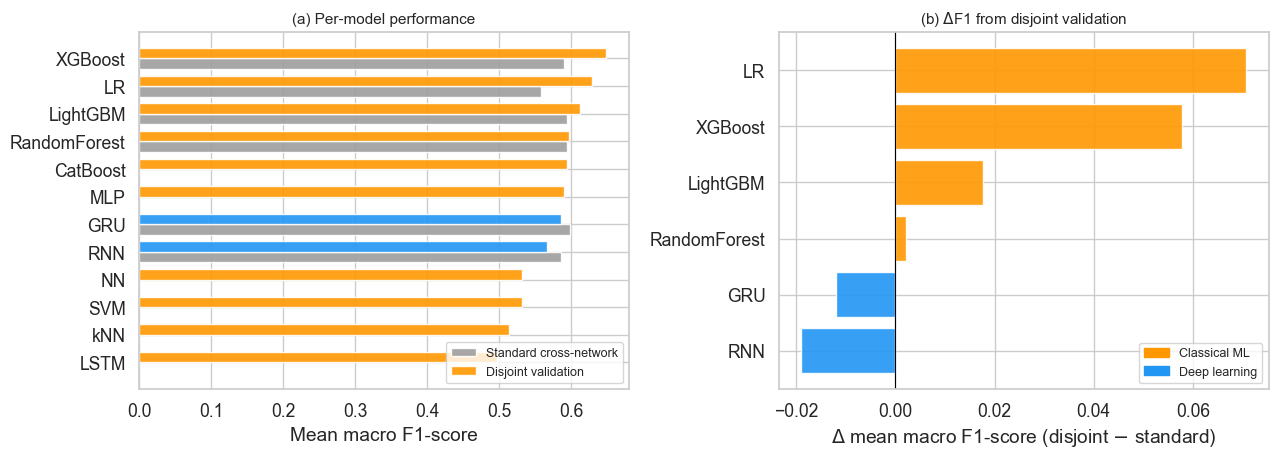

Saved paper_fig_q5_models.{pdf,png}


In [20]:
# ── Paper Figure (fig:q5_models): per-model disjoint vs standard + delta ──────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
GREY_STD = '#9e9e9e'

cs_m = cs_avg.groupby(['model', 'category'])['mean_f1'].mean().reset_index()
std_m = (std_avg[std_avg['model'].isin(COMMON_MODELS)]
         .groupby('model')['mean_f1'].mean().reset_index()
         .rename(columns={'mean_f1': 'std_f1'}))
mdf = cs_m.merge(std_m, on='model', how='left').sort_values('mean_f1').reset_index(drop=True)
mdf['name'] = mdf['model'].map(PAPER_MODEL_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = np.arange(len(mdf)); w = 0.38
bar_cols = [DL_COLOR if c == 'Deep Learning' else CLS_COLOR for c in mdf['category']]

axes[0].barh(x - w/2, mdf['std_f1'].fillna(0), w, color=GREY_STD, alpha=0.9,
             label='Standard cross-network')
axes[0].barh(x + w/2, mdf['mean_f1'], w, color=bar_cols, alpha=0.9,
             label='Disjoint validation')
axes[0].set_yticks(x); axes[0].set_yticklabels(mdf['name'])
axes[0].set_xlabel('Mean macro F1-score')
axes[0].set_title('(a) Per-model performance', fontsize=11)
axes[0].legend(fontsize=9, loc='lower right')

ddf = mdf.dropna(subset=['std_f1']).copy()
ddf['delta'] = ddf['mean_f1'] - ddf['std_f1']
ddf = ddf.sort_values('delta').reset_index(drop=True)
dcols = [DL_COLOR if c == 'Deep Learning' else CLS_COLOR for c in ddf['category']]
axes[1].barh(ddf['name'], ddf['delta'], color=dcols, alpha=0.9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel(r'$\Delta$ mean macro F1-score (disjoint $-$ standard)')
axes[1].set_title(r'(b) $\Delta$F1 from disjoint validation', fontsize=11)
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=CLS_COLOR, label='Classical ML'),
                        Patch(color=DL_COLOR, label='Deep learning')],
               fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'paper_fig_q5_models.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'paper_fig_q5_models.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved paper_fig_q5_models.{pdf,png}')

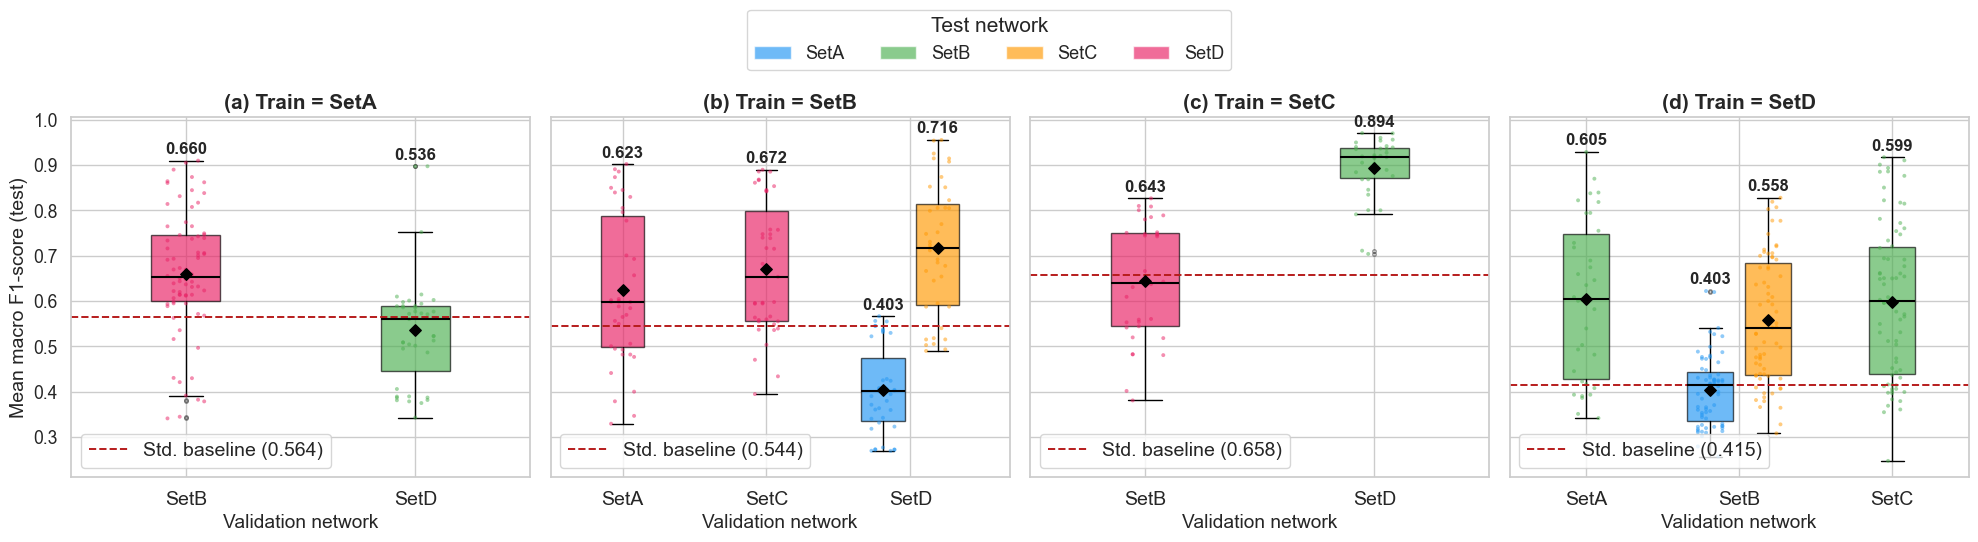

Saved paper_fig_q5_valset.{pdf,png}


In [21]:
# ── Paper Figure (fig:q5_valset): validation-network effect per training source ──
# WHAT THIS PLOT SHOWS. For each TRAINING network (one subplot), the disjoint-network
# case-study test F1 distribution across all models x tasks x splits. Boxes are grouped
# by VALIDATION network (x-axis) and COLOURED BY THE HELD-OUT TEST network (top legend).
# Because SetA/SetC are the same environment and every SetA/SetC co-occurrence is
# excluded, most (train, val) pairings keep a single valid test network; only the
# (train, val)=(*, SetB<->SetD) pairings retain two test networks (SetA and SetC).
# Black diamond = mean; the red dashed line = standard single-source cross-network
# baseline for that training source.
train_sets_used = sorted(cs_avg['train_set'].unique())
fig, axes = plt.subplots(1, len(train_sets_used),
                         figsize=(5.0 * len(train_sets_used), 4.8), sharey=True)
if len(train_sets_used) == 1:
    axes = [axes]

BOX_W = 0.30
for k, (ax, tr) in enumerate(zip(axes, train_sets_used)):
    sub = cs_avg[cs_avg['train_set'] == tr]
    val_nets = sorted(sub['val_set'].unique())
    positions, box_data, box_cols, tick_pos = [], [], [], []
    for xi, val in enumerate(val_nets):
        test_nets = sorted(sub[sub['val_set'] == val]['test_set'].unique())
        n = len(test_nets)
        offs = (np.arange(n) - (n - 1) / 2) * 0.38 if n > 1 else [0.0]
        for off, te in zip(offs, test_nets):
            vals = sub[(sub['val_set'] == val) & (sub['test_set'] == te)]['mean_f1'].values
            positions.append(xi + off)
            box_data.append(vals)
            box_cols.append(NET_PAL.get(te, '#999'))
        tick_pos.append(xi)
    bp = ax.boxplot(box_data, positions=positions, widths=BOX_W, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.4))
    for patch, col in zip(bp['boxes'], box_cols):
        patch.set_facecolor(col)
        patch.set_alpha(0.65)
    jit = np.linspace(-0.08, 0.08, 7)
    for pos, vals, col in zip(positions, box_data, box_cols):
        ax.scatter(pos + np.resize(jit, len(vals)), vals, s=8, color=col,
                   alpha=0.5, edgecolors='none', zorder=2)
        ax.scatter(pos, vals.mean(), marker='D', color='black', s=34, zorder=5)
        ax.text(pos, vals.max() + 0.015, f'{vals.mean():.3f}', ha='center',
                fontsize=12, fontweight='bold')
    std_base = std_avg[std_avg['train_set'] == tr]['mean_f1'].mean()
    ax.axhline(std_base, color='#B71C1C', linestyle='--', linewidth=1.4,
               label=f'Std. baseline ({std_base:.3f})')
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(val_nets, rotation=0, fontsize=14)
    ax.set_title(f'({chr(97 + k)}) Train = {tr}', fontsize=15, fontweight='bold')
    ax.set_xlabel('Validation network')
    if k == 0:
        ax.set_ylabel('Mean macro F1-score (test)', fontsize=14)
    ax.legend(fontsize=14, loc='lower left')

# Shared legend: box colour -> held-out test network
from matplotlib.patches import Patch
test_handles = [Patch(facecolor=NET_PAL[s], alpha=0.65, label=s) for s in NETWORKS]
fig.legend(handles=test_handles, title='Test network', ncol=len(NETWORKS),
           loc='upper center', bbox_to_anchor=(0.5, 1.15), fontsize=13, title_fontsize=15)
# fig.suptitle('Effect of validation-network choice on disjoint-network test F1\n'
            #  '(each box: test-F1 over all models, tasks and splits; black diamond = mean)',
            #  y=1.17, fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'paper_fig_q5_valset.pdf', bbox_inches='tight')
plt.savefig(FIG_DIR / 'paper_fig_q5_valset.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved paper_fig_q5_valset.{pdf,png}')